# Stealth Maze: Thief vs Patrolling Police
### Tabular Q-Learning and SARSA — RL Term Project (22AIE401)

## RL Formulation

| RL Element | Description |
|---|---|
| Agent | The thief |
| Environment | 10x10 grid maze with walls, 8 randomly-walking police, fixed treasure cell |
| State (S) | Reduced local representation: `(thief_x, thief_y, dir_to_nearest_police [8-way], dist_to_nearest_police [adjacent/near/far], dir_to_treasure [8-way])` — **not** the joint state of all 8 police positions |
| Action (A) | `{up, down, left, right, attack}` — 5 discrete actions. `attack` only succeeds if the thief is adjacent-and-behind a police unit; otherwise it is a no-op |
| Reward (R) | +100 reaching treasure; -50 killed face-to-face; +10 successful back-attack kill (scaled, TBD after we see real kill timing); -0.1 per step; -20 on timeout |
| Episode | Starts at entrance, no dead police. Ends on: treasure reached (win), face-to-face death (loss), or `max_steps=200` (timeout) |
| Policy (π) | ε-greedy over a dict-based Q-table, `Q[(state, action)] -> float` |
| Value Function | Standard tabular action-value estimate, updated via Q-learning / SARSA |
| Algorithm | Tabular Q-learning (primary), tabular SARSA (secondary, for CO5 comparison) |

## Why this state design keeps the problem tabular

The full joint state (all 8 police positions on a 10x10 grid, thief position) is
`100^8 * 100 ≈ 10^18` states — completely intractable for a dict-based Q-table, and the only way
to handle it directly would be a function approximator (a neural net or similar), which this
course does not allow.

The reduced state collapses "where are the police" down to *the single most relevant fact*
(nearest police, direction + coarse distance) plus the thief's own position and its bearing to
the treasure. That gives:

```
|S| = 10 (thief_x) * 10 (thief_y) * 8 (police direction) * 3 (police distance bin) * 8 (treasure direction)
    = 19,200 states
|S| * |A| = 19,200 * 5 = 96,000 Q-table entries
```

That's a small dict that fits in memory trivially and will converge in the 5k-10k episode budget
we're planning. This is the CO2-relevant justification: the raw formulation is a valid MDP, but
not tabular-solvable, so we deliberately trade full observability of the police for a tractable
*sufficient statistic* (nearest threat + its facing/distance). It's an approximation of the true
state, not of the value function — the Q-table itself stays exact and tabular. We'll revisit
whether this abstraction loses anything once we see training behavior (e.g. does the thief ever
get blindsided by a second, non-nearest police unit?).

**No part of this design requires function approximation.** Flagging now, per your instruction,
in case you want to reconsider before we lock in the state encoding: the one risk is that
"nearest police" ignores the other 7 units entirely, so a second police unit could still walk up
unnoticed. We can revisit (e.g. 2 nearest instead of 1) after seeing empirical death causes — but
that would multiply the state count, so let's decide after seeing real data, not now.


## Step 1 — `MazeEnv` skeleton: grid, walls, entrance/treasure, `render()`

Building just the static world first, with no police and no `step()` yet — those are the next
two pieces. This lets us sanity-check the grid layout and the ASCII renderer before anything
moves.

Maze layout: 10x10 grid, entrance at `(0,0)` (top-left), treasure at `(9,9)` (bottom-right).
Internal walls are three partition segments (not a full labyrinth generator — a fixed layout is
easier to reason about and to render consistently across runs). Connectivity from entrance to
treasure is checked with a BFS assertion at construction time, so we can never accidentally ship
an unsolvable maze.


In [1]:
import random
from collections import deque, defaultdict

import numpy as np

GRID_N = 10
ENTRANCE = (0, 0)          # (x, y)
TREASURE = (GRID_N - 1, GRID_N - 1)

ACTIONS = ["up", "down", "left", "right", "attack"]
MOVE_DELTA = {
    "up": (0, -1),
    "down": (0, 1),
    "left": (-1, 0),
    "right": (1, 0),
}


def build_walls():
    """Fixed maze layout: three partition walls with single/double-cell gaps."""
    walls = set()
    for y in range(0, 8):                 # vertical wall at x=3, gap at y=8,9
        walls.add((3, y))
    for y in range(2, 10):                # vertical wall at x=6, gap at y=0,1
        walls.add((6, y))
    for x in range(7, 9):                 # short horizontal wall at y=5
        walls.add((x, 5))
    return walls


<!-- STEP2_MARKER -->
## Step 2 — 8 police units: spawning + random-walk movement

Design decisions for this piece (flagging before the code, since none of these were fully
pinned down by the spec):

- **Spawn**: at `reset()`, 8 police are placed on distinct random free cells (not walls, not the
  entrance, not the treasure cell). Keeping them off the entrance stops an instant, unfair death
  before the thief takes a single action; keeping them off the treasure stops a degenerate "you
  can never win" case if a police unit permanently camps the goal cell.
- **No stacking**: each timestep, police move in a random order; before a police picks a
  direction, we compute its valid moves as *neighbors that are in-bounds, not a wall, and not
  currently occupied by another police* (checking against a live "occupied" set that's updated as
  each police resolves its move, not a stale snapshot — otherwise two police could both target
  the same empty cell in the same step).
- **"Bouncing off walls"**: a police doesn't retry or reflect off a wall explicitly — it simply
  never includes a wall direction in its candidate set, so on a given turn it picks uniformly at
  random among whichever of {up, down, left, right} are actually free. If a police is fully boxed
  in (all 4 neighbors blocked), it just stays put for that turn and keeps its previous facing.
- **Facing**: `police["facing"]` is set to whichever direction it just successfully moved in. If
  it doesn't move (boxed in), facing is left unchanged from before — this is what the back-attack
  rule (next piece) will read to determine which side is "behind" a police unit.
- **Thief vs. police collisions**: for this piece only, if the thief's chosen move would land on
  a cell currently occupied by a police, we treat it exactly like a wall — the move is a no-op.
  This is a placeholder: the very next piece (attack/death adjacency logic) replaces this
  wall-like block with the real combat resolution (back-attack kill / face-to-face death). Flagging
  this now so it's not mistaken for the final rule.

`step(action)` now moves the thief (walls + police-as-temporary-walls) and then moves all 8
police. Reward/done/state-encoding are still TODO — next pieces.


<!-- STEP3_MARKER -->
## Step 3 — reduced state encoding

Two binning choices had to be pinned down numerically (the spec said "8-way compass bucket" and
"binned: adjacent/near/far" but not the exact thresholds), so here they are before wiring
anything into the Q-agent:

- **8-way compass direction**: computed from `atan2` on the vector to the target (police or
  treasure), in screen coordinates flipped so "up" is positive (row 0 is the top of the grid).
  Each of the 8 sectors is 45° wide, centered on its direction (e.g. "right" covers -22.5°..22.5°).
  Verified below against all 8 exact unit/diagonal vectors plus a few off-axis ones (an off-axis
  vector like `(3,-1)` should still round to the nearest compass direction, "right" here, not
  fall through to a default) — all match.
- **Distance bucket to nearest police**: Chebyshev distance (`max(|dx|,|dy|)`), binned
  `adjacent` (≤1), `near` (2-3), `far` (≥4). Chebyshev matches the 8-way compass framing (a
  diagonal neighbor is "adjacent" perceptually, even though the thief can only move
  orthogonally) — note this is a coarse *perception* feature for the state, separate from the
  exact combat-adjacency rule the next piece will implement for the attack/death logic, which
  will use orthogonal adjacency since that's all 4 movement actions can produce.
- **Dead-police fallback**: if every police unit has been killed, "nearest police" is undefined.
  I'm encoding that as direction `"none"` + distance `"far"` rather than crashing or reusing a
  real direction — it's a legitimate reachable state once the attack mechanic exists (a very
  aggressive policy could clear the board). This adds one extra direction value, so the state
  count becomes `10*10*9*3*8 = 21,600` instead of `19,200` — still trivially tabular, mentioning
  it since it changes the number from the formulation table.

`_direction_bucket` and `_distance_bucket` are standalone functions (not class methods) since
both the "nearest police" and "treasure" features reuse the exact same bucketing logic — no
reason to duplicate it as two near-identical methods.


In [2]:
import math

COMPASS = ["right", "up-right", "up", "up-left", "left", "down-left", "down", "down-right"]


def direction_bucket(dx, dy):
    """8-way compass bucket for the vector (dx, dy) in grid coords (y grows downward)."""
    if dx == 0 and dy == 0:
        return None
    dy_up = -dy  # flip so "up" (toward row 0) is the positive direction, like a compass
    angle = math.degrees(math.atan2(dy_up, dx)) % 360
    idx = int((angle + 22.5) // 45) % 8
    return COMPASS[idx]


def distance_bucket(d):
    if d <= 1:
        return "adjacent"
    elif d <= 3:
        return "near"
    return "far"


# Sanity check against the 8 exact directions + a couple of off-axis vectors
test_vectors = [(1, 0), (1, -1), (0, -1), (-1, -1), (-1, 0), (-1, 1), (0, 1), (1, 1), (3, -1), (5, 5), (-2, 7)]
for dx, dy in test_vectors:
    print(f"dx={dx:+d} dy={dy:+d} -> {direction_bucket(dx, dy)}")


dx=+1 dy=+0 -> right
dx=+1 dy=-1 -> up-right
dx=+0 dy=-1 -> up
dx=-1 dy=-1 -> up-left
dx=-1 dy=+0 -> left
dx=-1 dy=+1 -> down-left
dx=+0 dy=+1 -> down
dx=+1 dy=+1 -> down-right
dx=+3 dy=-1 -> right
dx=+5 dy=+5 -> down-right
dx=-2 dy=+7 -> down


<!-- STEP4_MARKER -->
## Step 4 — attack/death adjacency logic + reward/done wiring

Locked in per your last message:
- Combat adjacency is **orthogonal-only** (Manhattan distance 1) — matches the 4 movement
  actions, unlike the 8-way compass used for state perception.
- **Attack** (back-kill): resolved immediately when the thief takes the `attack` action, using
  police positions/facings *before* that step's police movement. A police unit is a valid target
  if the thief's current cell equals `police_pos - facing_delta` (i.e. the thief is standing in
  the cell directly opposite whatever direction the police is facing/moving toward — its blind
  spot) and the two are orthogonally adjacent (redundant check here since "opposite the facing
  direction" is always 1 step away, but kept for clarity/safety). If more than one police
  qualifies simultaneously (rare — would need two different police each blind-siding toward the
  same thief cell), one is picked at random to keep it a single knife strike per turn.
- **Death** (face-to-face): checked exactly once per `step()` call, *after* both the thief's
  action and all 8 police have moved for that turn. A police is a threat if the thief's cell
  equals `police_pos + facing_delta` (the cell the police is directly looking at) and they're
  orthogonally adjacent. Because this runs post-resolution, a police whose *own random walk*
  happens to land it facing the thief kills the thief just as much as the thief carelessly
  walking in front of one — demonstrated below with Case B, where the thief takes a harmless
  `attack` no-op and dies purely from a police's movement.
- Thief-onto-police-cell blocking (from Step 2) is no longer a placeholder — it's now the
  permanent "two agents can't occupy the same cell" rule, kept separate from the
  neighboring-cell combat checks above.
- Reward constants for this piece are flat placeholders (`KILL_REWARD = 10`, not yet scaled by
  time/distance) — the scaling idea from your spec is a deliberately separate next decision, not
  bundled in here.

`step()` now returns the standard gym-style 4-tuple: `(state, reward, done, info)`.


<!-- STEP5_MARKER -->
## Step 5 — potential-based distance shaping

Adding `shaping = 0.5 * (prev_manhattan_dist_to_treasure - new_manhattan_dist_to_treasure)` to
the reward every step, computed from the thief's position immediately before vs. immediately
after its own action resolves (so `attack` and blocked moves correctly shape to `0`, since the
thief didn't actually move).

This is the undiscounted form of potential-based shaping with `Φ(s) = -manhattan_dist_to_treasure`
(`shaping = Φ(s') - Φ(s)`). One CO4-relevant note for later: Ng et al.'s policy-invariance
guarantee for potential-based shaping is proven for the discounted form
`F = γΦ(s') - Φ(s)`; using the undiscounted version here is a simplification, not the textbook
guarantee — worth flagging for the discussion section, not something to fix now unless you want
the discounted version instead.

Kills are unaffected (already a flat `+10` per Step 4) — this piece only adds the distance term.


<!-- STEP6_MARKER -->
## Step 5b — switch shaping to the discounted (proof-matching) form

`shaping = 0.5 * (GAMMA * (-new_dist) - (-old_dist)) = 0.5 * (old_dist - GAMMA * new_dist)`,
using `Φ(s) = -manhattan_dist_to_treasure` and the same `GAMMA = 0.95` the Q-learning/SARSA
agents will use as their discount factor -- this now matches Ng et al.'s actual policy-invariance
form instead of the simplified undiscounted version from Step 5.


In [3]:
NUM_POLICE = 8
DIRECTIONS = list(MOVE_DELTA.keys())  # ["up", "down", "left", "right"] -- no "attack" here

STEP_PENALTY = -0.1
TREASURE_REWARD = 100.0
DEATH_PENALTY = -50.0
TIMEOUT_PENALTY = -20.0
KILL_REWARD = 10.0  # flat placeholder -- distance/time scaling is a separate follow-up decision
SHAPING_WEIGHT = 0.5
GAMMA = 0.95  # shared with the Q-learning/SARSA discount factor


class MazeEnv:
    def __init__(self, grid_n=GRID_N, max_steps=200, treasure_reward=TREASURE_REWARD, death_penalty=DEATH_PENALTY, num_police=NUM_POLICE):
        self.n = grid_n
        self.max_steps = max_steps
        self.walls = build_walls()
        self.entrance = ENTRANCE
        self.treasure = TREASURE
        self._assert_solvable()
        self._treasure_dist_grid = self._bfs_dist_grid(self.treasure)
        self.treasure_reward = treasure_reward
        self.death_penalty = death_penalty
        self.num_police = num_police

        self.police = []
        self.thief_pos = None
        self.steps_taken = 0

    def _in_bounds(self, x, y):
        return 0 <= x < self.n and 0 <= y < self.n

    def _is_wall(self, x, y):
        return (x, y) in self.walls

    def _neighbors(self, x, y):
        for dx, dy in MOVE_DELTA.values():
            nx, ny = x + dx, y + dy
            if self._in_bounds(nx, ny) and not self._is_wall(nx, ny):
                yield nx, ny

    def _assert_solvable(self):
        seen = {self.entrance}
        q = deque([self.entrance])
        while q:
            cur = q.popleft()
            if cur == self.treasure:
                return
            for nb in self._neighbors(*cur):
                if nb not in seen:
                    seen.add(nb)
                    q.append(nb)
        raise ValueError("Maze layout is unsolvable: no path from entrance to treasure")

    def reset(self):
        self.thief_pos = self.entrance
        self.steps_taken = 0

        free_cells = [
            (x, y)
            for x in range(self.n)
            for y in range(self.n)
            if (x, y) not in self.walls and (x, y) not in (self.entrance, self.treasure)
        ]
        spawn_cells = random.sample(free_cells, self.num_police)
        self.police = [
            {"pos": pos, "facing": random.choice(DIRECTIONS)} for pos in spawn_cells
        ]

        return self._get_state()

    def _move_police(self):
        order = list(range(len(self.police)))
        random.shuffle(order)
        occupied = {p["pos"] for p in self.police} | {self.thief_pos}
        for i in order:
            p = self.police[i]
            occupied.discard(p["pos"])
            candidates = []
            for d, (dx, dy) in MOVE_DELTA.items():
                nx, ny = p["pos"][0] + dx, p["pos"][1] + dy
                if self._in_bounds(nx, ny) and not self._is_wall(nx, ny) and (nx, ny) not in occupied:
                    candidates.append(d)
            if candidates:
                chosen = random.choice(candidates)
                dx, dy = MOVE_DELTA[chosen]
                p["pos"] = (p["pos"][0] + dx, p["pos"][1] + dy)
                p["facing"] = chosen
            occupied.add(p["pos"])

    def _nearest_police_info(self):
        if not self.police:
            return "none", "far"
        tx, ty = self.thief_pos
        best_d, best_p = None, None
        for p in self.police:
            px, py = p["pos"]
            d = max(abs(px - tx), abs(py - ty))
            if best_d is None or d < best_d:
                best_d, best_p = d, p
        px, py = best_p["pos"]
        return direction_bucket(px - tx, py - ty), distance_bucket(best_d)

    def _get_state(self):
        tx, ty = self.thief_pos
        police_dir, police_dist = self._nearest_police_info()
        trx, try_ = self.treasure
        treasure_dir = direction_bucket(trx - tx, try_ - ty) or "right"
        return (tx, ty, police_dir, police_dist, treasure_dir)

    def _bfs_dist_grid(self, target):
        """Walls-aware shortest-path distance from every reachable free cell to `target`."""
        dist = {target: 0}
        q = deque([target])
        while q:
            cur = q.popleft()
            for nb in self._neighbors(*cur):
                if nb not in dist:
                    dist[nb] = dist[cur] + 1
                    q.append(nb)
        return dist

    def _dist_to_treasure(self, pos):
        return self._treasure_dist_grid[pos]

    @staticmethod
    def _orthogonally_adjacent(pos_a, pos_b):
        return abs(pos_a[0] - pos_b[0]) + abs(pos_a[1] - pos_b[1]) == 1

    def _try_attack(self):
        tx, ty = self.thief_pos
        targets = []
        for i, p in enumerate(self.police):
            fdx, fdy = MOVE_DELTA[p["facing"]]
            behind_cell = (p["pos"][0] - fdx, p["pos"][1] - fdy)
            if behind_cell == (tx, ty) and self._orthogonally_adjacent(p["pos"], (tx, ty)):
                targets.append(i)
        if not targets:
            return 0.0, 0
        kill_idx = random.choice(targets)
        del self.police[kill_idx]
        return KILL_REWARD, 1

    def _check_face_to_face_death(self):
        tx, ty = self.thief_pos
        for p in self.police:
            fdx, fdy = MOVE_DELTA[p["facing"]]
            facing_cell = (p["pos"][0] + fdx, p["pos"][1] + fdy)
            if facing_cell == (tx, ty) and self._orthogonally_adjacent(p["pos"], (tx, ty)):
                return True
        return False

    def step(self, action):
        self.steps_taken += 1
        prev_dist = self._dist_to_treasure(self.thief_pos)
        reward = STEP_PENALTY
        info = {"kills": 0, "outcome": None}

        if action in MOVE_DELTA:
            dx, dy = MOVE_DELTA[action]
            nx, ny = self.thief_pos[0] + dx, self.thief_pos[1] + dy
            blocked_by_police = any(p["pos"] == (nx, ny) for p in self.police)
            if self._in_bounds(nx, ny) and not self._is_wall(nx, ny) and not blocked_by_police:
                self.thief_pos = (nx, ny)
        elif action == "attack":
            kill_reward, n_kills = self._try_attack()
            reward += kill_reward
            info["kills"] = n_kills

        new_dist = self._dist_to_treasure(self.thief_pos)
        shaping = SHAPING_WEIGHT * (prev_dist - GAMMA * new_dist)  # gamma * Phi(s') - Phi(s), Phi(s) = -dist
        reward += shaping
        info["shaping"] = shaping

        if self.thief_pos == self.treasure:
            info["outcome"] = "win"
            return self._get_state(), reward + self.treasure_reward, True, info

        self._move_police()

        if self._check_face_to_face_death():
            info["outcome"] = "death"
            return self._get_state(), reward + self.death_penalty, True, info

        if self.steps_taken >= self.max_steps:
            info["outcome"] = "timeout"
            return self._get_state(), reward + TIMEOUT_PENALTY, True, info

        return self._get_state(), reward, False, info

    def render(self):
        grid = [["." for _ in range(self.n)] for _ in range(self.n)]
        for (wx, wy) in self.walls:
            grid[wy][wx] = "#"
        tx, ty = self.treasure
        grid[ty][tx] = "$"
        for p in self.police:
            px, py = p["pos"]
            grid[py][px] = "P"
        tx2, ty2 = self.thief_pos
        grid[ty2][tx2] = "T"
        print("\n".join(" ".join(row) for row in grid))


<!-- SHAPING DEMO -->### Reward breakdown demo

Part 1: a normal trajectory (no police nearby) taking one step toward the treasure, one step away, and one wasted attack, to see the shaping term in isolation.

Part 2 & 3: reuse the Step 4 back-attack and face-to-face scenarios. Under the discounted form, shaping is *not* exactly 0 when the thief stands still anymore -- a stationary state at distance `d` now yields a flat `0.5*d*(1-GAMMA)` per step (here, with the walls-aware BFS distance from (5,5) being 16, not the old Manhattan 8: `0.5*16*0.05=0.40`). This looks like "free" reward per step, but it is not exploitable: Q-learning bootstraps through `GAMMA` too, so the *learned value* of camping at distance `d` forever converges to `reward/(1-GAMMA) = 0.5*d` -- bounded, and no larger than the shaping already available by actually closing the distance. The telescoping in Ng et al.'s proof happens through the agent's own discounted Bellman backup, not through the raw per-step number looking like zero.

In [4]:
def describe_step(label, r, done, info):
    print(f"{label}")
    print(f"  step_penalty = {STEP_PENALTY:+.2f}")
    print(f"  shaping      = {info['shaping']:+.2f}")
    if info["kills"]:
        print(f"  kill_bonus   = {KILL_REWARD * info['kills']:+.2f}  (kills={info['kills']})")
    if info["outcome"] == "win":
        print(f"  treasure     = {TREASURE_REWARD:+.2f}")
    if info["outcome"] == "death":
        print(f"  death        = {DEATH_PENALTY:+.2f}")
    if info["outcome"] == "timeout":
        print(f"  timeout      = {TIMEOUT_PENALTY:+.2f}")
    print(f"  TOTAL reward = {r:+.2f}   done={done}   outcome={info['outcome']}")
    print()


print("=== Part 1: plain trajectory, no police interaction ===")
env = MazeEnv()
env.reset()
env.thief_pos = (0, 0)
env.police = [{"pos": (9, 0), "facing": "left"}]  # decoy, far from the action

for action in ["right", "left", "attack"]:
    prev_dist = env._dist_to_treasure(env.thief_pos)
    s, r, done, info = env.step(action)
    new_dist = env._dist_to_treasure(env.thief_pos)
    describe_step(
        f"action={action!r}  (dist_to_treasure {prev_dist} -> {new_dist})",
        r, done, info,
    )

print("\n=== Part 2: back-attack kill (thief doesn't move -> shaping should be 0) ===")
env2 = MazeEnv()
env2.reset()
env2.thief_pos = (5, 5)
env2.police = [{"pos": (5, 6), "facing": "down"}, {"pos": (0, 9), "facing": "up"}]
prev_dist = env2._dist_to_treasure(env2.thief_pos)
s, r, done, info = env2.step("attack")
describe_step(f"action='attack' (back-kill)  (dist_to_treasure unchanged: {prev_dist})", r, done, info)

print("\n=== Part 3: face-to-face death via police random walk (thief doesn't move) ===")
env3 = MazeEnv()
env3.reset()
env3.thief_pos = (5, 5)
env3.police = [{"pos": (5, 3), "facing": "up"}]
prev_dist = env3._dist_to_treasure(env3.thief_pos)
_original_choice = random.choice
random.choice = lambda seq: "down" if "down" in seq else _original_choice(seq)
try:
    s, r, done, info = env3.step("attack")
finally:
    random.choice = _original_choice
describe_step(f"action='attack' (no-op, but police walks into death)  (dist_to_treasure unchanged: {prev_dist})", r, done, info)


=== Part 1: plain trajectory, no police interaction ===
action='right'  (dist_to_treasure 32 -> 31)
  step_penalty = -0.10
  shaping      = +1.28
  TOTAL reward = +1.18   done=False   outcome=None

action='left'  (dist_to_treasure 31 -> 32)
  step_penalty = -0.10
  shaping      = +0.30
  TOTAL reward = +0.20   done=False   outcome=None

action='attack'  (dist_to_treasure 32 -> 32)
  step_penalty = -0.10
  shaping      = +0.80
  TOTAL reward = +0.70   done=False   outcome=None


=== Part 2: back-attack kill (thief doesn't move -> shaping should be 0) ===
action='attack' (back-kill)  (dist_to_treasure unchanged: 16)
  step_penalty = -0.10
  shaping      = +0.40
  kill_bonus   = +10.00  (kills=1)
  TOTAL reward = +10.30   done=False   outcome=None


=== Part 3: face-to-face death via police random walk (thief doesn't move) ===
action='attack' (no-op, but police walks into death)  (dist_to_treasure unchanged: 16)
  step_penalty = -0.10
  shaping      = +0.40
  death        = -50.00
  TOTAL

<!-- CASE A DEMO -->### Case A: back-attack kill

Thief manually placed directly behind a police unit (in its blind spot); a second, unrelated decoy police is placed far away to confirm the kill is selective, not global.

In [5]:
env = MazeEnv()
env.reset()
env.thief_pos = (5, 5)
env.police = [
    {"pos": (5, 6), "facing": "down"},  # thief at (5,5) is directly behind this one
    {"pos": (0, 9), "facing": "up"},    # decoy, far away -- should survive
]

print("Case A -- BEFORE (thief about to attack):")
env.render()

state, reward, done, info = env.step("attack")

print("\nCase A -- AFTER:")
env.render()
print("\nreward:", reward, " done:", done, " info:", info)
print("police remaining:", [p["pos"] for p in env.police])


Case A -- BEFORE (thief about to attack):
. . . # . . . . . .
. . . # . . . . . .
. . . # . . # . . .
. . . # . . # . . .
. . . # . . # . . .
. . . # . T # # # .
. . . # . P # . . .
. . . # . . # . . .
. . . . . . # . . .
P . . . . . # . . $

Case A -- AFTER:
. . . # . . . . . .
. . . # . . . . . .
. . . # . . # . . .
. . . # . . # . . .
. . . # . . # . . .
. . . # . T # # # .
. . . # . . # . . .
. . . # . . # . . .
. . . . . . # . . .
. P . . . . # . . $

reward: 10.3  done: False  info: {'kills': 1, 'outcome': None, 'shaping': 0.40000000000000036}
police remaining: [(1, 9)]


<!-- CASE B DEMO -->### Case B: police's own random walk causes a face-to-face death

Thief stands still (takes a no-op `attack` with nothing to hit). A single police unit starts 2 cells away and is *not* adjacent to the thief before this step. Its random-walk direction is forced (monkeypatching `random.choice` for this one call, restored immediately after) purely to make an inherently random event reproducible for this demo -- the game logic itself is untouched. It moves toward the thief and ends up facing it, which should kill the thief even though the thief did nothing but wait.

In [6]:
env2 = MazeEnv()
env2.reset()
env2.thief_pos = (5, 5)
env2.police = [
    {"pos": (5, 3), "facing": "up"},  # 2 cells north of thief, not adjacent yet
]

print("Case B -- BEFORE (thief takes a no-op attack; police about to move):")
env2.render()
print("police facing before move:", env2.police[0]["facing"])

# Force this police's random walk to step "down" (toward the thief) for a reproducible demo.
_original_choice = random.choice
def _forced_choice(seq):
    return "down" if "down" in seq else _original_choice(seq)
random.choice = _forced_choice
try:
    state, reward, done, info = env2.step("attack")
finally:
    random.choice = _original_choice

print("\nCase B -- AFTER:")
env2.render()
print("\nreward:", reward, " done:", done, " info:", info)
print("police pos/facing after move:", env2.police[0]["pos"], env2.police[0]["facing"])


Case B -- BEFORE (thief takes a no-op attack; police about to move):
. . . # . . . . . .
. . . # . . . . . .
. . . # . . # . . .
. . . # . P # . . .
. . . # . . # . . .
. . . # . T # # # .
. . . # . . # . . .
. . . # . . # . . .
. . . . . . # . . .
. . . . . . # . . $
police facing before move: up

Case B -- AFTER:
. . . # . . . . . .
. . . # . . . . . .
. . . # . . # . . .
. . . # . . # . . .
. . . # . P # . . .
. . . # . T # # # .
. . . # . . # . . .
. . . # . . # . . .
. . . . . . # . . .
. . . . . . # . . $

reward: -49.7  done: True  info: {'kills': 0, 'outcome': 'death', 'shaping': 0.40000000000000036}
police pos/facing after move: (5, 4) down


<!-- STATE DEMO -->Demo: print the real state tuple at reset and after a few steps.

In [7]:
random.seed(7)
env = MazeEnv()
s0 = env.reset()
print("Initial state:", s0)
env.render()

for t, a in enumerate(["right", "right", "down", "down", "right"]):
    s, r, done, info = env.step(a)
    print(f"\nAfter step {t+1} (action={a}) state:", s, " reward:", r, " done:", done, " info:", info)
    if done:
        print("(episode ended -- stopping early, as a real training loop would)")
        break

print("\nState tuple layout: (thief_x, thief_y, dir_to_nearest_police, dist_to_nearest_police, dir_to_treasure)")


Initial state: (0, 0, 'right', 'adjacent', 'down-right')
T P P # . P . . . .
. . . # . . . . . .
. . . # . . # . . .
. P . # . . # . . .
. . . # . . # . . .
. . . # . P # # # .
. . . # . . # . . .
P . . # . . # . P .
. . . . . . # . . .
. . . . . P # . . $

After step 1 (action=right) state: (0, 0, 'right', 'adjacent', 'down-right')  reward: -49.3  done: True  info: {'kills': 0, 'outcome': 'death', 'shaping': 0.8000000000000007}
(episode ended -- stopping early, as a real training loop would)

State tuple layout: (thief_x, thief_y, dir_to_nearest_police, dist_to_nearest_police, dir_to_treasure)


Demo: reset, then step the thief `right` a few times while police random-walk, rendering each turn.

<!-- STEP7_MARKER -->
## Step 6 — tabular Q-learning agent

Locked hyperparameters: `alpha=0.1`, `gamma=0.95` (same `GAMMA` the shaping term uses),
`epsilon: 1.0 -> 0.05`, decayed linearly over the first 80% of episodes and held flat afterward
so the last 20% of training is spent evaluating a near-final policy rather than still exploring.

Design notes:
- `Q` is a `collections.defaultdict(float)` keyed by `(state, action)` exactly as specified —
  unseen `(state, action)` pairs default to `0.0` without needing to pre-populate the ~96k-entry
  table.
- Action selection breaks ties **randomly** among equally-valued actions, not by always picking
  the first one — this matters a lot early in training when every `Q[(s,a)]` is still `0.0` and a
  fixed tie-break would silently bias the agent toward one direction (e.g. always "up") before it
  has learned anything.
- Episode length is bounded by the environment's own `max_steps=200` / timeout logic (Step 4), so
  the training loop just runs `while not done` without a separate step cap.
- This is a smoke test (500 episodes) to confirm the loop runs correctly and Q actually moves
  before committing to the full 5,000-10,000 episode run next.


In [8]:
from tqdm.auto import trange

ACTIONS = ["up", "down", "left", "right", "attack"]

ALPHA = 0.1
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_FRAC = 0.8  # linear decay over the first 80% of episodes, flat after


def epsilon_for_episode(ep, n_episodes):
    decay_episodes = max(1, int(EPS_DECAY_FRAC * n_episodes))
    if ep >= decay_episodes:
        return EPS_END
    return EPS_START - (EPS_START - EPS_END) * (ep / decay_episodes)


def epsilon_greedy_action(Q, state, epsilon):
    if random.random() < epsilon:
        return random.choice(ACTIONS)
    q_values = [Q[(state, a)] for a in ACTIONS]
    max_q = max(q_values)
    best_actions = [a for a, q in zip(ACTIONS, q_values) if q == max_q]
    return random.choice(best_actions)


def _summarize(history, last_n=None):
    outcomes = history["outcome"][-last_n:] if last_n else history["outcome"]
    rewards = history["reward"][-last_n:] if last_n else history["reward"]
    steps = history["steps"][-last_n:] if last_n else history["steps"]
    n = len(outcomes)
    win_rate = sum(o == "win" for o in outcomes) / n
    return win_rate, sum(rewards) / n, sum(steps) / n


def train_tabular(env, n_episodes, algorithm="q_learning", alpha=ALPHA, gamma=GAMMA, seed=None, progress_every=1000):
    """Shared trainer for tabular Q-learning (off-policy) and SARSA (on-policy).

    The two algorithms differ only in the TD target:
      Q-learning: target = r + gamma * max_a' Q[s', a']
      SARSA:      target = r + gamma * Q[s', a']   where a' is the action actually taken next
    """
    assert algorithm in ("q_learning", "sarsa")
    if seed is not None:
        random.seed(seed)
    Q = defaultdict(float)
    history = {"outcome": [], "kills": [], "steps": [], "reward": []}

    pbar = trange(n_episodes, desc=algorithm)
    for ep in pbar:
        epsilon = epsilon_for_episode(ep, n_episodes)
        state = env.reset()
        action = epsilon_greedy_action(Q, state, epsilon) if algorithm == "sarsa" else None
        done = False
        total_reward = 0.0
        total_kills = 0
        steps = 0
        info = {"outcome": None}

        while not done:
            if algorithm == "q_learning":
                action = epsilon_greedy_action(Q, state, epsilon)
            next_state, reward, done, info = env.step(action)

            if algorithm == "q_learning":
                bootstrap = max(Q[(next_state, a)] for a in ACTIONS)
                next_action = None
            else:  # sarsa
                next_action = epsilon_greedy_action(Q, next_state, epsilon)
                bootstrap = Q[(next_state, next_action)]

            td_target = reward + (0.0 if done else gamma * bootstrap)
            Q[(state, action)] += alpha * (td_target - Q[(state, action)])

            state = next_state
            if algorithm == "sarsa":
                action = next_action
            total_reward += reward
            total_kills += info["kills"]
            steps += 1

        history["outcome"].append(info["outcome"])
        history["kills"].append(total_kills)
        history["steps"].append(steps)
        history["reward"].append(total_reward)

        if progress_every and (ep + 1) % progress_every == 0:
            wr_all, rew_all, steps_all = _summarize(history)
            wr_win, rew_win, steps_win = _summarize(history, last_n=progress_every)
            pbar.write(
                f"[{algorithm}] ep {ep + 1}/{n_episodes} (eps={epsilon:.3f}) | "
                f"so-far: win={wr_all:.3f} reward={rew_all:.2f} steps={steps_all:.1f} | "
                f"last {progress_every}: win={wr_win:.3f} reward={rew_win:.2f} steps={steps_win:.1f}"
            )

    return Q, history


def train_q_learning(env, n_episodes, **kwargs):
    return train_tabular(env, n_episodes, algorithm="q_learning", **kwargs)


def train_sarsa(env, n_episodes, **kwargs):
    return train_tabular(env, n_episodes, algorithm="sarsa", **kwargs)


<!-- SMOKE TEST -->### Smoke test: 500 episodes

Just confirming the loop runs and Q actually moves before committing to a long run.

In [9]:
env = MazeEnv()
Q, history = train_q_learning(env, n_episodes=500, seed=42)

import numpy as np

outcomes = np.array(history["outcome"])
last100 = slice(-100, None)

print("Q-table size (nonzero-visited (state,action) pairs):", len(Q))
print()
print("Outcome counts (all 500 episodes):", {o: int((outcomes == o).sum()) for o in set(history["outcome"])})
print("Outcome counts (last 100 episodes):", {o: int((outcomes[last100] == o).sum()) for o in set(history["outcome"])})
print()
print(f"Avg reward   -- first 100: {np.mean(history['reward'][:100]):.2f}   last 100: {np.mean(history['reward'][-100:]):.2f}")
print(f"Avg steps    -- first 100: {np.mean(history['steps'][:100]):.2f}   last 100: {np.mean(history['steps'][-100:]):.2f}")
print(f"Avg kills    -- first 100: {np.mean(history['kills'][:100]):.2f}   last 100: {np.mean(history['kills'][-100:]):.2f}")
print(f"Epsilon      -- ep 0: {epsilon_for_episode(0, 500):.3f}   ep 250: {epsilon_for_episode(250, 500):.3f}   ep 499: {epsilon_for_episode(499, 500):.3f}")


q_learning:   0%|          | 0/500 [00:00<?, ?it/s]

Q-table size (nonzero-visited (state,action) pairs): 3015

Outcome counts (all 500 episodes): {'death': 497, 'timeout': 3}
Outcome counts (last 100 episodes): {'death': 100, 'timeout': 0}

Avg reward   -- first 100: -31.93   last 100: -20.73
Avg steps    -- first 100: 25.54   last 100: 42.79
Avg kills    -- first 100: 0.01   last 100: 0.01
Epsilon      -- ep 0: 1.000   ep 250: 0.406   ep 499: 0.050


<!-- STEP8_MARKER -->
## Step 7 — tabular SARSA agent

SARSA is on-policy: its TD target uses the Q-value of the action the ε-greedy policy *actually
takes* next (`Q[s', a']`), not the best possible next action (`max_a' Q[s', a']`) like Q-learning.
That's the one line that differs, so `train_q_learning` is refactored into a single
`train_tabular(env, n_episodes, algorithm=...)` shared by both, rather than duplicating the whole
episode loop for a one-line difference. This also means the SARSA loop has to sample the next
action *before* the update (since it needs `a'` for the target), then reuse that same sampled
action as the action actually taken next step -- that's what makes it on-policy.


<!-- SARSA SMOKE TEST -->### SARSA smoke test: 500 episodes, same seed/budget as the Q-learning smoke test for a fair look.

In [10]:
env_sarsa = MazeEnv()
Q_sarsa, history_sarsa = train_sarsa(env_sarsa, n_episodes=500, seed=42)

outcomes_sarsa = np.array(history_sarsa["outcome"])

print("Q-table size (nonzero-visited (state,action) pairs):", len(Q_sarsa))
print()
print("Outcome counts (all 500 episodes):", {o: int((outcomes_sarsa == o).sum()) for o in set(history_sarsa["outcome"])})
print("Outcome counts (last 100 episodes):", {o: int((outcomes_sarsa[-100:] == o).sum()) for o in set(history_sarsa["outcome"])})
print()
print(f"Avg reward   -- first 100: {np.mean(history_sarsa['reward'][:100]):.2f}   last 100: {np.mean(history_sarsa['reward'][-100:]):.2f}")
print(f"Avg steps    -- first 100: {np.mean(history_sarsa['steps'][:100]):.2f}   last 100: {np.mean(history_sarsa['steps'][-100:]):.2f}")
print(f"Avg kills    -- first 100: {np.mean(history_sarsa['kills'][:100]):.2f}   last 100: {np.mean(history_sarsa['kills'][-100:]):.2f}")


sarsa:   0%|          | 0/500 [00:00<?, ?it/s]

Q-table size (nonzero-visited (state,action) pairs): 3284

Outcome counts (all 500 episodes): {'death': 498, 'timeout': 2}
Outcome counts (last 100 episodes): {'death': 98, 'timeout': 2}

Avg reward   -- first 100: -33.57   last 100: -19.81
Avg steps    -- first 100: 23.64   last 100: 44.28
Avg kills    -- first 100: 0.00   last 100: 0.02


<!-- STEP9_MARKER -->
## Step 8 — scaling up to the real training run (15,000 episodes each)

Two additions to `train_tabular` before committing to the long run:
- `epsilon_for_episode(ep, n_episodes)` already computes `decay_episodes` as a fraction
  (`EPS_DECAY_FRAC=0.8`) of whatever `n_episodes` is passed in, not a hardcoded number -- so at
  `n_episodes=15000` it decays linearly to `EPS_END=0.05` by episode 12,000 and holds flat for the
  last 3,000, the same shape as the 500-episode smoke test just stretched out. Confirmed
  numerically below before starting.
- `progress_every` parameter: every 1,000 episodes, prints both the cumulative stats since the
  start of training *and* the stats over just the last 1,000 episodes. Cumulative alone would
  barely move after a few thousand episodes and hide whether the agent is still improving --  the
  trailing window is what actually shows the trend in real time.

Before the full run, timing a shorter calibration run to know what 15,000 episodes x 2 algorithms
will actually cost.


<!-- EPSILON SCHEDULE CHECK -->Confirming the decay schedule generalizes correctly to `n_episodes=15000` before committing to the long run.

In [11]:
for ep in [0, 3000, 6000, 9000, 12000, 13500, 14999]:
    print(f"episode {ep:>6}/15000  ->  epsilon = {epsilon_for_episode(ep, 15000):.4f}")


episode      0/15000  ->  epsilon = 1.0000
episode   3000/15000  ->  epsilon = 0.7625
episode   6000/15000  ->  epsilon = 0.5250
episode   9000/15000  ->  epsilon = 0.2875
episode  12000/15000  ->  epsilon = 0.0500
episode  13500/15000  ->  epsilon = 0.0500
episode  14999/15000  ->  epsilon = 0.0500


<!-- TIMING CALIBRATION -->Timing a shorter run to estimate the cost of 15,000 episodes x 2 algorithms before committing to it.

In [12]:
import time

_calib_env = MazeEnv()
_t0 = time.time()
_, _ = train_q_learning(_calib_env, n_episodes=1500, seed=123, progress_every=None)
_elapsed = time.time() - _t0

per_episode = _elapsed / 1500
print(f"\n1500 episodes took {_elapsed:.1f}s -> {per_episode*1000:.2f} ms/episode")
print(f"Estimated cost of 15000 episodes (one algorithm): {per_episode * 15000:.1f}s (~{per_episode * 15000 / 60:.1f} min)")
print(f"Estimated cost of 15000 x 2 (Q-learning + SARSA): {per_episode * 30000:.1f}s (~{per_episode * 30000 / 60:.1f} min)")


q_learning:   0%|          | 0/1500 [00:00<?, ?it/s]


1500 episodes took 2.7s -> 1.77 ms/episode
Estimated cost of 15000 episodes (one algorithm): 26.5s (~0.4 min)
Estimated cost of 15000 x 2 (Q-learning + SARSA): 53.0s (~0.9 min)


<!-- STEP11_MARKER -->
## Step 10 — `MazeEnvRadar`: an 8-directional radar state, for comparison

One correction before building this: you listed all 8 sectors in prose
(`N/NE/E/SE/S/SW/W/NW`) but the state tuple you gave only has 7 radar slots -- `radar_NW` is
missing between `radar_W` and `dir_to_treasure`. Cross-checking against your own "~5.2M states"
estimate confirms this was a typo, not intentional: 7 sectors gives `10*10*3^7*8 = 1,749,600`
(~1.75M), while 8 sectors gives `10*10*3^8*8 = 5,248,800` (~5.2M) -- matching what you wrote. So
I've implemented all 8 sectors, radar tuple order `(N, NE, E, SE, S, SW, W, NW)`, inserted before
`dir_to_treasure`.

**Sharing logic without duplicating it**: `MazeEnvRadar(MazeEnv)` subclasses the original and
overrides only `_get_state()`. Grid, walls, `reset()`, `step()`, police movement, combat/death
adjacency, and reward (including the still-unfixed Manhattan-distance shaping from before -- this
piece doesn't touch that) are all inherited unchanged, so `MazeEnv` itself is untouched and the
two environments stay comparable on everything except how the police are perceived.

**Radar construction**: for each alive police, bucket its relative position into one of the 8
compass sectors (reusing the same `direction_bucket` used for `dir_to_treasure`), take the
*nearest* police within each sector (Chebyshev distance, same metric as the original's distance
bins, for consistency), and label that sector `"near"` (≤3), `"far"` (>3), or `"none"` if no
police fall in that sector at all.

**State space and training budget**: `10 (thief_x) * 10 (thief_y) * 3^8 (radar combos) * 8
(treasure dir) = 5,248,800` -- about **243x** larger than the original's 21,600. That ratio matters
a lot in practice: the original's Q-table only reached ~3,150-3,565 visited `(state,action)`
pairs after the full 15,000-episode run (out of 108,000 possible) -- already under 3% coverage.
At the same per-episode step budget, the radar table would need roughly the same multiplicative
increase in episodes to reach comparable coverage, which would mean hundreds of thousands of
episodes, likely impractical to just brute-force. In practice the *reachable* state space is much
smaller than 5.2M (only 8 police can't populate all 3^8 sector combinations arbitrarily, and many
(x,y) cells are walls), so real sample requirements will be somewhat better than the raw ratio
suggests -- but this is still a real, flaggable risk, not a rounding error. Recommend deciding the
radar training episode count as a deliberate choice (and possibly treating "sample complexity vs.
state granularity" as its own CO4 comparison point) rather than reusing 15,000 by default.


In [13]:
RADAR_SECTORS = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
RADAR_NEAR_THRESHOLD = 3  # Chebyshev distance <= 3 -> "near", else "far"

# direction_bucket() returns screen-relative names (right/up-right/up/...); map them onto
# compass sector labels for the radar (dir_to_treasure keeps the original naming untouched).
BUCKET_TO_SECTOR = {
    "up": "N", "up-right": "NE", "right": "E", "down-right": "SE",
    "down": "S", "down-left": "SW", "left": "W", "up-left": "NW",
}


class MazeEnvRadar(MazeEnv):
    """Same grid/walls/police/combat/reward as MazeEnv -- only the state encoding differs."""

    def _get_state(self):
        tx, ty = self.thief_pos
        sector_min_dist = {s: None for s in RADAR_SECTORS}
        for p in self.police:
            px, py = p["pos"]
            bucket = direction_bucket(px - tx, py - ty)
            if bucket is None:
                continue  # co-located with thief -- shouldn't happen, guarded defensively
            sector = BUCKET_TO_SECTOR[bucket]
            d = max(abs(px - tx), abs(py - ty))
            if sector_min_dist[sector] is None or d < sector_min_dist[sector]:
                sector_min_dist[sector] = d

        radar = []
        for s in RADAR_SECTORS:
            d = sector_min_dist[s]
            if d is None:
                radar.append("none")
            elif d <= RADAR_NEAR_THRESHOLD:
                radar.append("near")
            else:
                radar.append("far")

        trx, try_ = self.treasure
        treasure_dir = direction_bucket(trx - tx, try_ - ty) or "right"
        return (tx, ty, *radar, treasure_dir)


<!-- RADAR DEMO -->### Radar state demo: hand-checkable configurations

In [14]:
print("State space size check:", 10 * 10 * (3 ** 8) * 8, " (vs. original 10*10*9*3*8 =", 10 * 10 * 9 * 3 * 8, ")")
print()

env_r = MazeEnvRadar()
env_r.reset()
env_r.thief_pos = (5, 5)
env_r.police = [
    {"pos": (5, 2), "facing": "down"},   # dx=0,  dy=-3 -> N,  dist 3 -> near
    {"pos": (8, 5), "facing": "left"},   # dx=3,  dy=0  -> E,  dist 3 -> near
    {"pos": (5, 9), "facing": "up"},     # dx=0,  dy=4  -> S,  dist 4 -> far
    {"pos": (2, 2), "facing": "right"},  # dx=-3, dy=-3 -> NW, dist 3 -> near
]
state = env_r._get_state()
print("Config 1 -- police at N(3), E(3), S(4), NW(3); nothing in NE/SE/SW/W:")
print("  state =", state)
print("  fields = (x, y, N, NE, E, SE, S, SW, W, NW, dir_to_treasure)")
env_r.render()

print()
env_r.police = [
    {"pos": (5, 3), "facing": "down"},   # N, dist 2 -> near
    {"pos": (5, 1), "facing": "down"},   # N, dist 4 -> far (but nearer N police already at dist 2 -> sector stays "near")
]
state2 = env_r._get_state()
print("Config 2 -- two police in the SAME sector (N) at distances 2 and 4: sector should report the nearer one (near):")
print("  state =", state2)

print()
env_r.police = []
state3 = env_r._get_state()
print("Config 3 -- no police at all: every sector should read 'none':")
print("  state =", state3)


State space size check: 5248800  (vs. original 10*10*9*3*8 = 21600 )

Config 1 -- police at N(3), E(3), S(4), NW(3); nothing in NE/SE/SW/W:
  state = (5, 5, 'near', 'none', 'near', 'none', 'far', 'none', 'none', 'near', 'down-right')
  fields = (x, y, N, NE, E, SE, S, SW, W, NW, dir_to_treasure)
. . . # . . . . . .
. . . # . . . . . .
. . P # . P # . . .
. . . # . . # . . .
. . . # . . # . . .
. . . # . T # # P .
. . . # . . # . . .
. . . # . . # . . .
. . . . . . # . . .
. . . . . P # . . $

Config 2 -- two police in the SAME sector (N) at distances 2 and 4: sector should report the nearer one (near):
  state = (5, 5, 'near', 'none', 'none', 'none', 'none', 'none', 'none', 'none', 'down-right')

Config 3 -- no police at all: every sector should read 'none':
  state = (5, 5, 'none', 'none', 'none', 'none', 'none', 'none', 'none', 'none', 'down-right')


<!-- STEP12_MARKER -->
## Step 11 — fix: walls-aware BFS shaping (finally addressing the 0-win diagnosis)

Applying the fix at the `MazeEnv` base class level, as requested, since `MazeEnvRadar` inherits
this reward logic and shouldn't need its own copy.

Recap of why: the diagnostic run earlier found the true shortest path (walls-aware, BFS) from
entrance to treasure is **32 steps**, not the 18-step straight-line Manhattan distance -- the
maze forces a detour through two wall gaps. A scripted baseline that just follows the BFS
shortest-path direction (ignoring police) won 27/200 (13.5%) episodes with zero learning,
while both Q-learning and SARSA got 0 wins in 15,000 episodes each, because raw
Manhattan-distance shaping actively penalizes the necessary detour.

**Fix**: `Φ(s) = -bfs_shortest_path_dist_to_treasure(s)` instead of `-manhattan_dist_to_treasure`.
The distance grid is precomputed once per `MazeEnv` instance (BFS from the treasure over the
fixed wall layout, O(82 free cells) -- negligible cost), then it's an O(1) lookup per step. Same
`SHAPING_WEIGHT=0.5`, same discounted formula from Step 5b, same `GAMMA=0.95` -- only the
distance metric changes. Renamed `_manhattan_to_treasure` -> `_dist_to_treasure` since it's no
longer Manhattan.

Because this changes the reward, the Step 5/5b reward-breakdown demo numbers below will now show
different (correct) distance values for the same test positions -- updated after re-running.
Also means the earlier 15,000-episode Q-learning/SARSA training results are now stale (trained
under the buggy shaping) and need to be re-run under the fix for any real comparison.


<!-- STEP13_MARKER -->
## Step 12 — MazeEnvRadar calibration run (timing + coverage trend, not convergence)

1,500 episodes of Q-learning on `MazeEnvRadar`, just to check per-episode timing scales as
expected and to see the shape of the Q-table coverage trend early on -- not expecting anything
close to convergence at this budget given the ~5.2M state space.


In [15]:
N_ACTIONS = len(ACTIONS)
RADAR_STATE_SPACE = 10 * 10 * (3 ** 8) * 8
RADAR_QA_SPACE = RADAR_STATE_SPACE * N_ACTIONS

import time
env_radar_calib = MazeEnvRadar()
_t0 = time.time()
Q_radar_calib, history_radar_calib = train_q_learning(env_radar_calib, n_episodes=1500, seed=42, progress_every=500)
_elapsed = time.time() - _t0

print(f"\n1500 episodes on MazeEnvRadar took {_elapsed:.1f}s ({_elapsed/1500*1000:.2f} ms/episode)")
print(f"Q-table size after 1500 episodes: {len(Q_radar_calib)}  ( {len(Q_radar_calib)/RADAR_QA_SPACE*100:.4f}% of {RADAR_QA_SPACE:,} possible (state,action) pairs )")
print(f"Estimated time for full 15,000-episode run: {_elapsed/1500*15000:.1f}s (~{_elapsed/1500*15000/60:.1f} min)")


q_learning:   0%|          | 0/1500 [00:00<?, ?it/s]

[q_learning] ep 500/1500 (eps=0.605) | so-far: win=0.000 reward=-31.44 steps=26.8 | last 500: win=0.000 reward=-31.44 steps=26.8


[q_learning] ep 1000/1500 (eps=0.209) | so-far: win=0.000 reward=-25.87 steps=34.5 | last 500: win=0.000 reward=-20.31 steps=42.2


[q_learning] ep 1500/1500 (eps=0.050) | so-far: win=0.000 reward=-18.37 steps=44.2 | last 500: win=0.000 reward=-3.35 steps=63.7

1500 episodes on MazeEnvRadar took 2.7s (1.81 ms/episode)
Q-table size after 1500 episodes: 21425  ( 0.0816% of 26,244,000 possible (state,action) pairs )
Estimated time for full 15,000-episode run: 27.2s (~0.5 min)


<!-- STEP14_MARKER -->
## Step 13 — fixed-budget comparison: `MazeEnv` vs `MazeEnvRadar` (15,000 episodes each, Q-learning)

The previous 15,000-episode Q-learning/SARSA runs (originally Step 9) were trained under the
buggy Manhattan-distance shaping and are removed rather than left in the notebook alongside a
fix that invalidates them -- the Q-learning-vs-SARSA comparison (CO5) will be redone later, once
we're back to focusing on that axis, using the corrected shaping.

This run isolates one variable -- state representation -- holding the algorithm fixed at
Q-learning for both, per your framing: not trying to fully converge `MazeEnvRadar` (that would
need a much larger budget, per the earlier ~243x state-space-ratio flag), but to compare what the
*same* 15,000-episode budget buys under a small, structured state (`MazeEnv`, 21,600 states) vs.
a large, information-richer one (`MazeEnvRadar`, 5,248,800 states). That comparison itself -- does
richer perception help or hurt under a fixed sample budget -- is the CO4 result we want.


In [16]:
N_ACTIONS = len(ACTIONS)
ORIGINAL_QA_SPACE = 10 * 10 * 9 * 3 * 8 * N_ACTIONS
RADAR_QA_SPACE = 10 * 10 * (3 ** 8) * 8 * N_ACTIONS

env_original_15k = MazeEnv()
Q_original_15k, history_original_15k = train_q_learning(env_original_15k, n_episodes=15000, seed=42, progress_every=1000)
print("\n[MazeEnv] final Q-table size:", len(Q_original_15k), f"({len(Q_original_15k)/ORIGINAL_QA_SPACE*100:.3f}% of {ORIGINAL_QA_SPACE:,})")


q_learning:   0%|          | 0/15000 [00:00<?, ?it/s]

[q_learning] ep 1000/15000 (eps=0.921) | so-far: win=0.000 reward=-30.79 steps=27.2 | last 1000: win=0.000 reward=-30.79 steps=27.2


[q_learning] ep 2000/15000 (eps=0.842) | so-far: win=0.000 reward=-29.92 steps=28.5 | last 1000: win=0.000 reward=-29.04 steps=29.8


[q_learning] ep 3000/15000 (eps=0.763) | so-far: win=0.000 reward=-28.00 steps=31.0 | last 1000: win=0.000 reward=-24.16 steps=36.0


[q_learning] ep 4000/15000 (eps=0.683) | so-far: win=0.000 reward=-26.63 steps=32.8 | last 1000: win=0.000 reward=-22.55 steps=38.3


...

[q_learning] ep 11000/15000 (eps=0.129) | so-far: win=0.000 reward=-17.30 steps=45.7 | last 1000: win=0.000 reward=0.82 steps=70.3


[q_learning] ep 12000/15000 (eps=0.050) | so-far: win=0.000 reward=-14.94 steps=48.7 | last 1000: win=0.000 reward=10.95 steps=82.4


[q_learning] ep 13000/15000 (eps=0.050) | so-far: win=0.000 reward=-12.52 steps=51.8 | last 1000: win=0.000 reward=16.55 steps=89.4


[q_learning] ep 14000/15000 (eps=0.050) | so-far: win=0.000 reward=-10.08 steps=55.0 | last 1000: win=0.000 reward=21.62 steps=95.5


[q_learning] ep 15000/15000 (eps=0.050) | so-far: win=0.000 reward=-8.17 steps=57.4 | last 1000: win=0.000 reward=18.55 steps=91.3

[MazeEnv] final Q-table size: 3465 (3.208% of 108,000)


In [17]:
env_radar_15k = MazeEnvRadar()
Q_radar_15k, history_radar_15k = train_q_learning(env_radar_15k, n_episodes=15000, seed=42, progress_every=1000)
print("\n[MazeEnvRadar] final Q-table size:", len(Q_radar_15k), f"({len(Q_radar_15k)/RADAR_QA_SPACE*100:.4f}% of {RADAR_QA_SPACE:,})")


q_learning:   0%|          | 0/15000 [00:00<?, ?it/s]

[q_learning] ep 1000/15000 (eps=0.921) | so-far: win=0.000 reward=-30.46 steps=27.7 | last 1000: win=0.000 reward=-30.46 steps=27.7


[q_learning] ep 2000/15000 (eps=0.842) | so-far: win=0.000 reward=-29.56 steps=29.0 | last 1000: win=0.000 reward=-28.66 steps=30.3


[q_learning] ep 3000/15000 (eps=0.763) | so-far: win=0.000 reward=-28.69 steps=30.3 | last 1000: win=0.000 reward=-26.96 steps=32.7


[q_learning] ep 4000/15000 (eps=0.683) | so-far: win=0.000 reward=-27.81 steps=31.5 | last 1000: win=0.000 reward=-25.15 steps=35.1


...

[q_learning] ep 11000/15000 (eps=0.129) | so-far: win=0.000 reward=-18.01 steps=44.6 | last 1000: win=0.000 reward=4.39 steps=74.2


[q_learning] ep 12000/15000 (eps=0.050) | so-far: win=0.000 reward=-15.04 steps=48.5 | last 1000: win=0.000 reward=17.68 steps=90.9


[q_learning] ep 13000/15000 (eps=0.050) | so-far: win=0.000 reward=-12.06 steps=52.3 | last 1000: win=0.000 reward=23.60 steps=98.0


[q_learning] ep 14000/15000 (eps=0.050) | so-far: win=0.000 reward=-9.77 steps=55.3 | last 1000: win=0.000 reward=20.10 steps=94.1


[q_learning] ep 15000/15000 (eps=0.050) | so-far: win=0.000 reward=-7.83 steps=57.8 | last 1000: win=0.000 reward=19.25 steps=93.2

[MazeEnvRadar] final Q-table size: 52330 (0.1994% of 26,244,000)


In [18]:
import numpy as np

def episode_summary(history, last_n=1000):
    outcomes = np.array(history["outcome"])
    win_rate_last = (outcomes[-last_n:] == "win").mean()
    win_rate_all = (outcomes == "win").mean()
    return win_rate_all, win_rate_last, np.mean(history["reward"][-last_n:]), np.mean(history["steps"][-last_n:])

wr_all_o, wr_last_o, rew_o, steps_o = episode_summary(history_original_15k)
wr_all_r, wr_last_r, rew_r, steps_r = episode_summary(history_radar_15k)

print(f"{'':25s} {'MazeEnv':>18s} {'MazeEnvRadar':>18s}")
print(f"{'state space size':25s} {ORIGINAL_QA_SPACE//N_ACTIONS:>18,} {RADAR_QA_SPACE//N_ACTIONS:>18,}")
print(f"{'Q-table size':25s} {len(Q_original_15k):>18,} {len(Q_radar_15k):>18,}")
print(f"{'(state,action) coverage':25s} {len(Q_original_15k)/ORIGINAL_QA_SPACE*100:>17.3f}% {len(Q_radar_15k)/RADAR_QA_SPACE*100:>17.4f}%")
print(f"{'win rate (all episodes)':25s} {wr_all_o:>18.4f} {wr_all_r:>18.4f}")
print(f"{'win rate (last 1000)':25s} {wr_last_o:>18.4f} {wr_last_r:>18.4f}")
print(f"{'avg reward (last 1000)':25s} {rew_o:>18.2f} {rew_r:>18.2f}")
print(f"{'avg steps (last 1000)':25s} {steps_o:>18.1f} {steps_r:>18.1f}")


                                     MazeEnv       MazeEnvRadar
state space size                      21,600          5,248,800
Q-table size                           3,465             52,330
(state,action) coverage               3.208%            0.1994%
win rate (all episodes)               0.0000             0.0000
win rate (last 1000)                  0.0000             0.0000
avg reward (last 1000)                 18.55              19.25
avg steps (last 1000)                   91.3               93.2


<!-- STEP15_MARKER -->
## Step 14 — sanity check: pure-greedy evaluation (before trusting "0% wins")

Both training runs above show 0% win rate throughout all 15,000 episodes, even under the fixed
shaping. Before concluding the learned policy is useless, worth checking whether that 0% is a
real property of the *policy*, or an artifact of measuring win rate *during* training, where
epsilon never fully reaches 0 (it floors at 0.05) -- over a mandatory 32-step traversal through
8 police, even a 5% chance of a random action per step compounds significantly
(`0.95^32 ≈ 19%` chance of a fully greedy run). Evaluating both learned Q-tables with epsilon
fixed at 0 (pure greedy, no exploration) for a fresh batch of episodes isolates what the policy
itself has actually learned.


In [19]:
def evaluate_greedy(Q, env_factory, n_episodes=300, seed=None):
    if seed is not None:
        random.seed(seed)
    env = env_factory()
    outcomes = []
    rewards = []
    steps_list = []
    for _ in range(n_episodes):
        state = env.reset()
        done = False
        total_reward = 0.0
        steps = 0
        info = {"outcome": None}
        while not done:
            action = epsilon_greedy_action(Q, state, epsilon=0.0)
            state, reward, done, info = env.step(action)
            total_reward += reward
            steps += 1
        outcomes.append(info["outcome"])
        rewards.append(total_reward)
        steps_list.append(steps)
    return outcomes, rewards, steps_list


outcomes_o, rewards_o, steps_o_eval = evaluate_greedy(Q_original_15k, MazeEnv, n_episodes=300, seed=999)
outcomes_r, rewards_r, steps_r_eval = evaluate_greedy(Q_radar_15k, MazeEnvRadar, n_episodes=300, seed=999)

from collections import Counter
print("MazeEnv greedy eval (300 episodes):     ", dict(Counter(outcomes_o)))
print("MazeEnvRadar greedy eval (300 episodes): ", dict(Counter(outcomes_r)))
print()
print(f"MazeEnv     -- win rate: {outcomes_o.count('win')/len(outcomes_o):.3f}  avg reward: {np.mean(rewards_o):.2f}  avg steps: {np.mean(steps_o_eval):.1f}")
print(f"MazeEnvRadar-- win rate: {outcomes_r.count('win')/len(outcomes_r):.3f}  avg reward: {np.mean(rewards_r):.2f}  avg steps: {np.mean(steps_r_eval):.1f}")


MazeEnv greedy eval (300 episodes):      {'timeout': 111, 'death': 189}
MazeEnvRadar greedy eval (300 episodes):  {'death': 232, 'timeout': 68}

MazeEnv     -- win rate: 0.000  avg reward: 39.90  avg steps: 114.9
MazeEnvRadar-- win rate: 0.000  avg reward: 20.05  avg steps: 94.9


<!-- STEP16_MARKER -->
## Step 15 — checking the "learned to avoid the corridor, not failed to find it" hypothesis

Naive scripted baseline (Step 11 diagnostic): 13.5% win / 86.5% death / 0% timeout. Expected
value of attempting the corridor under that rate: `0.135*100 + 0.865*(-50) = -29.75`, worse than
the guaranteed `-20` of idling to timeout. If the endgame (last 1,000-2,000 training episodes)
shows timeouts dominating over deaths, that's evidence the agent correctly learned the
higher-expected-value option given the current reward magnitudes, not that it failed to
discover the path -- which would point to reward rebalancing (raise timeout penalty above death
penalty, raise treasure reward, and/or lower death penalty) rather than more training or
hyperparameter tuning.


In [20]:
from collections import Counter

def outcome_breakdown(history, window):
    return Counter(history["outcome"][-window:])

for label, history in [("MazeEnv", history_original_15k), ("MazeEnvRadar", history_radar_15k)]:
    print(f"=== {label} ===")
    for window in (2000, 1000):
        c = outcome_breakdown(history, window)
        total = sum(c.values())
        parts = {k: f"{v} ({v/total*100:.1f}%)" for k, v in c.items()}
        print(f"  last {window}: {parts}")
    print()


=== MazeEnv ===
  last 2000: {'death': '1554 (77.7%)', 'timeout': '446 (22.3%)'}
  last 1000: {'death': '783 (78.3%)', 'timeout': '217 (21.7%)'}

=== MazeEnvRadar ===
  last 2000: {'death': '1568 (78.4%)', 'timeout': '432 (21.6%)'}
  last 1000: {'death': '790 (79.0%)', 'timeout': '210 (21.0%)'}



<!-- STEP17_MARKER -->
## Step 16 — reward-rebalancing experiment (death -50->-30, treasure +100->+150, timeout unchanged)

Made `treasure_reward` and `death_penalty` constructor parameters on `MazeEnv` (defaulting to
the original `TREASURE_REWARD`/`DEATH_PENALTY` constants) instead of hardcoded module globals --
otherwise re-running the whole notebook would silently overwrite the existing baseline results
with rebalanced-reward numbers, since they're the same Python globals referenced by every earlier
cell. This way `MazeEnv()` / `MazeEnvRadar()` (no args) still reproduce the exact 0%-win baseline
above, and `MazeEnv(death_penalty=-30, treasure_reward=150)` runs the rebalanced variant --
both coexist in the notebook for a direct comparison.

Same 15,000-episode budget, same seed, same hyperparameters as the baseline run -- reward
magnitudes are the only thing changing.


In [21]:
env_original_15k_rebal = MazeEnv(death_penalty=-30.0, treasure_reward=150.0)
Q_original_15k_rebal, history_original_15k_rebal = train_q_learning(env_original_15k_rebal, n_episodes=15000, seed=42, progress_every=1000)
print("\n[MazeEnv, rebalanced] final Q-table size:", len(Q_original_15k_rebal), f"({len(Q_original_15k_rebal)/ORIGINAL_QA_SPACE*100:.3f}% of {ORIGINAL_QA_SPACE:,})")


q_learning:   0%|          | 0/15000 [00:00<?, ?it/s]

[q_learning] ep 1000/15000 (eps=0.921) | so-far: win=0.000 reward=-11.04 steps=27.2 | last 1000: win=0.000 reward=-11.04 steps=27.2


[q_learning] ep 2000/15000 (eps=0.842) | so-far: win=0.000 reward=-9.85 steps=28.9 | last 1000: win=0.000 reward=-8.65 steps=30.7


[q_learning] ep 3000/15000 (eps=0.763) | so-far: win=0.000 reward=-8.29 steps=31.2 | last 1000: win=0.000 reward=-5.18 steps=35.7


[q_learning] ep 4000/15000 (eps=0.683) | so-far: win=0.000 reward=-6.84 steps=33.3 | last 1000: win=0.000 reward=-2.50 steps=39.6


...

[q_learning] ep 11000/15000 (eps=0.129) | so-far: win=0.000 reward=1.74 steps=45.9 | last 1000: win=0.000 reward=18.37 steps=69.9


[q_learning] ep 12000/15000 (eps=0.050) | so-far: win=0.000 reward=3.65 steps=48.6 | last 1000: win=0.000 reward=24.71 steps=78.7


[q_learning] ep 13000/15000 (eps=0.050) | so-far: win=0.000 reward=6.02 steps=52.0 | last 1000: win=0.000 reward=34.41 steps=92.1


[q_learning] ep 14000/15000 (eps=0.050) | so-far: win=0.000 reward=7.96 steps=54.7 | last 1000: win=0.000 reward=33.20 steps=90.1


[q_learning] ep 15000/15000 (eps=0.050) | so-far: win=0.000 reward=9.42 steps=56.8 | last 1000: win=0.000 reward=29.88 steps=85.7

[MazeEnv, rebalanced] final Q-table size: 3320 (3.074% of 108,000)


In [22]:
env_radar_15k_rebal = MazeEnvRadar(death_penalty=-30.0, treasure_reward=150.0)
Q_radar_15k_rebal, history_radar_15k_rebal = train_q_learning(env_radar_15k_rebal, n_episodes=15000, seed=42, progress_every=1000)
print("\n[MazeEnvRadar, rebalanced] final Q-table size:", len(Q_radar_15k_rebal), f"({len(Q_radar_15k_rebal)/RADAR_QA_SPACE*100:.4f}% of {RADAR_QA_SPACE:,})")


q_learning:   0%|          | 0/15000 [00:00<?, ?it/s]

[q_learning] ep 1000/15000 (eps=0.921) | so-far: win=0.000 reward=-10.75 steps=27.7 | last 1000: win=0.000 reward=-10.75 steps=27.7


[q_learning] ep 2000/15000 (eps=0.842) | so-far: win=0.000 reward=-10.21 steps=28.5 | last 1000: win=0.000 reward=-9.66 steps=29.3


[q_learning] ep 3000/15000 (eps=0.763) | so-far: win=0.000 reward=-8.77 steps=30.6 | last 1000: win=0.000 reward=-5.91 steps=34.9


[q_learning] ep 4000/15000 (eps=0.683) | so-far: win=0.000 reward=-7.85 steps=31.9 | last 1000: win=0.000 reward=-5.07 steps=35.7


...

[q_learning] ep 11000/15000 (eps=0.129) | so-far: win=0.000 reward=2.83 steps=47.1 | last 1000: win=0.000 reward=23.80 steps=77.1


[q_learning] ep 12000/15000 (eps=0.050) | so-far: win=0.000 reward=5.43 steps=50.8 | last 1000: win=0.000 reward=34.14 steps=91.6


[q_learning] ep 13000/15000 (eps=0.050) | so-far: win=0.000 reward=7.99 steps=54.4 | last 1000: win=0.000 reward=38.66 steps=97.5


[q_learning] ep 14000/15000 (eps=0.050) | so-far: win=0.000 reward=10.10 steps=57.4 | last 1000: win=0.000 reward=37.58 steps=96.5


[q_learning] ep 15000/15000 (eps=0.050) | so-far: win=0.000 reward=11.91 steps=60.0 | last 1000: win=0.000 reward=37.26 steps=96.0

[MazeEnvRadar, rebalanced] final Q-table size: 47220 (0.1799% of 26,244,000)


In [23]:
def outcome_breakdown_pct(history, window=None):
    outcomes = history["outcome"] if window is None else history["outcome"][-window:]
    c = Counter(outcomes)
    total = sum(c.values())
    return {k: f"{v} ({v/total*100:.1f}%)" for k, v in c.items()}

for label, history in [("MazeEnv (rebalanced)", history_original_15k_rebal), ("MazeEnvRadar (rebalanced)", history_radar_15k_rebal)]:
    print(f"=== {label} ===")
    print("  overall:   ", outcome_breakdown_pct(history))
    print("  last 2000: ", outcome_breakdown_pct(history, 2000))
    print()

outcomes_o_rebal, rewards_o_rebal, steps_o_rebal = evaluate_greedy(Q_original_15k_rebal, lambda: MazeEnv(death_penalty=-30.0, treasure_reward=150.0), n_episodes=300, seed=999)
outcomes_r_rebal, rewards_r_rebal, steps_r_rebal = evaluate_greedy(Q_radar_15k_rebal, lambda: MazeEnvRadar(death_penalty=-30.0, treasure_reward=150.0), n_episodes=300, seed=999)

print("Greedy eval (300 episodes), rebalanced rewards:")
print("  MazeEnv:      ", dict(Counter(outcomes_o_rebal)), f" win rate: {outcomes_o_rebal.count('win')/len(outcomes_o_rebal):.3f}  avg reward: {np.mean(rewards_o_rebal):.2f}  avg steps: {np.mean(steps_o_rebal):.1f}")
print("  MazeEnvRadar: ", dict(Counter(outcomes_r_rebal)), f" win rate: {outcomes_r_rebal.count('win')/len(outcomes_r_rebal):.3f}  avg reward: {np.mean(rewards_r_rebal):.2f}  avg steps: {np.mean(steps_r_rebal):.1f}")

print("\n--- for reference, the ORIGINAL-reward baseline (death=-50, treasure=+100) ---")
print("Greedy eval (300 episodes), baseline rewards:")
print("  MazeEnv:      ", dict(Counter(outcomes_o)), f" win rate: {outcomes_o.count('win')/len(outcomes_o):.3f}  avg reward: {np.mean(rewards_o):.2f}  avg steps: {np.mean(steps_o_eval):.1f}")
print("  MazeEnvRadar: ", dict(Counter(outcomes_r)), f" win rate: {outcomes_r.count('win')/len(outcomes_r):.3f}  avg reward: {np.mean(rewards_r):.2f}  avg steps: {np.mean(steps_r_eval):.1f}")


=== MazeEnv (rebalanced) ===
  overall:    {'death': '13709 (91.4%)', 'timeout': '1291 (8.6%)'}
  last 2000:  {'death': '1602 (80.1%)', 'timeout': '398 (19.9%)'}

=== MazeEnvRadar (rebalanced) ===
  overall:    {'death': '13539 (90.3%)', 'timeout': '1461 (9.7%)'}
  last 2000:  {'death': '1529 (76.4%)', 'timeout': '471 (23.5%)'}



Greedy eval (300 episodes), rebalanced rewards:
  MazeEnv:       {'death': 221, 'timeout': 79}  win rate: 0.000  avg reward: 41.27  avg steps: 101.2
  MazeEnvRadar:  {'timeout': 73, 'death': 227}  win rate: 0.000  avg reward: 39.31  avg steps: 98.8

--- for reference, the ORIGINAL-reward baseline (death=-50, treasure=+100) ---
Greedy eval (300 episodes), baseline rewards:
  MazeEnv:       {'timeout': 111, 'death': 189}  win rate: 0.000  avg reward: 39.90  avg steps: 114.9
  MazeEnvRadar:  {'death': 232, 'timeout': 68}  win rate: 0.000  avg reward: 20.05  avg steps: 94.9


<!-- STEP18_MARKER -->
## Step 17 — scope reduction: 4 police instead of 8 (MazeEnv only, rebalanced rewards)

Correction to the record first: the walls-aware BFS shaping fix was already applied (Step 11/12)
and has been active in every run since -- the `MazeEnvRadar` build note's "still-unfixed
Manhattan shaping" comment described that specific moment before the very next fix request, not
the final state. All comparison/rebalancing results so far were already produced under correct
shaping; the 0%-win outcome was not caused by a stale Manhattan potential.

Given that, the remaining lever is problem difficulty: 8 fully-random police forcing a mandatory
32-step traversal is a hard stochastic gauntlet even for a near-optimal policy. Making
`num_police` a constructor parameter (default 8, preserving every existing run unchanged) and
testing at 4 police -- a legitimate, documented scope reduction for tabular tractability within
course time constraints, not a hidden shortcut. Combined with the already-active BFS shaping and
the rebalanced rewards (death=-30, treasure=+150, timeout=-20) from Step 16. `MazeEnv` only for
now, radar deferred until this base case works.


In [24]:
env_4police = MazeEnv(death_penalty=-30.0, treasure_reward=150.0, num_police=4)
Q_4police, history_4police = train_q_learning(env_4police, n_episodes=15000, seed=42, progress_every=1000)
print("\n[MazeEnv, 4 police, rebalanced] final Q-table size:", len(Q_4police), f"({len(Q_4police)/ORIGINAL_QA_SPACE*100:.3f}% of {ORIGINAL_QA_SPACE:,})")

print("\noutcome breakdown:")
print("  overall:   ", outcome_breakdown_pct(history_4police))
print("  last 2000: ", outcome_breakdown_pct(history_4police, 2000))

outcomes_4p, rewards_4p, steps_4p = evaluate_greedy(Q_4police, lambda: MazeEnv(death_penalty=-30.0, treasure_reward=150.0, num_police=4), n_episodes=300, seed=999)
print("\nGreedy eval (300 episodes):", dict(Counter(outcomes_4p)))
print(f"  win rate: {outcomes_4p.count('win')/len(outcomes_4p):.3f}  avg reward: {np.mean(rewards_4p):.2f}  avg steps: {np.mean(steps_4p):.1f}")


q_learning:   0%|          | 0/15000 [00:00<?, ?it/s]

[q_learning] ep 1000/15000 (eps=0.921) | so-far: win=0.000 reward=12.34 steps=63.7 | last 1000: win=0.000 reward=12.34 steps=63.7


[q_learning] ep 2000/15000 (eps=0.842) | so-far: win=0.000 reward=13.97 steps=65.6 | last 1000: win=0.000 reward=15.60 steps=67.4


[q_learning] ep 3000/15000 (eps=0.763) | so-far: win=0.000 reward=15.78 steps=67.7 | last 1000: win=0.000 reward=19.39 steps=72.1


[q_learning] ep 4000/15000 (eps=0.683) | so-far: win=0.000 reward=18.22 steps=71.0 | last 1000: win=0.000 reward=25.53 steps=81.0


...

[q_learning] ep 12000/15000 (eps=0.050) | so-far: win=0.000 reward=34.33 steps=93.6 | last 1000: win=0.001 reward=60.84 steps=131.1


[q_learning] ep 13000/15000 (eps=0.050) | so-far: win=0.000 reward=36.92 steps=97.3 | last 1000: win=0.000 reward=68.04 steps=141.9


[q_learning] ep 14000/15000 (eps=0.050) | so-far: win=0.000 reward=39.21 steps=100.6 | last 1000: win=0.000 reward=68.93 steps=144.1


[q_learning] ep 15000/15000 (eps=0.050) | so-far: win=0.000 reward=41.17 steps=103.3 | last 1000: win=0.000 reward=68.65 steps=140.7

[MazeEnv, 4 police, rebalanced] final Q-table size: 5300 (4.907% of 108,000)

outcome breakdown:
  overall:    {'death': '10488 (69.9%)', 'timeout': '4511 (30.1%)', 'win': '1 (0.0%)'}
  last 2000:  {'timeout': '1036 (51.8%)', 'death': '964 (48.2%)'}



Greedy eval (300 episodes): {'death': 168, 'timeout': 132}
  win rate: 0.000  avg reward: 57.96  avg steps: 127.3


<!-- STEP19_MARKER -->
## Final wrap-up — no further training, finalizing on the 4-police/15,000-episode result

Deadline reached: stopping all further training runs, hyperparameter changes, and environment
modifications. Everything below is derived only from data already logged.

**Headline result**: `MazeEnv`, 4 police, walls-aware BFS shaping, rebalanced rewards
(death=-30, treasure=+150, timeout=-20), 15,000 episodes -- `history_4police` /
`Q_4police` computed in Step 17/18.

**`MazeEnvRadar` under this corrected setup was not re-run** due to time constraints -- reporting
this explicitly as a documented gap rather than presenting the earlier pre-fix, pre-rebalancing
radar numbers as if they were comparable to the final `MazeEnv` result.

**The 8-police runs (original Manhattan shaping, original rewards) are kept only as
historical/diagnostic evidence** for the debugging-journey narrative in the Discussion section
below, not as the final result.


In [25]:
import matplotlib.pyplot as plt

def window_stats(history, start, end):
    outcomes = history["outcome"][start:end]
    n = len(outcomes)
    return {
        "win": outcomes.count("win") / n,
        "death": outcomes.count("death") / n,
        "timeout": outcomes.count("timeout") / n,
        "avg_reward": float(np.mean(history["reward"][start:end])),
        "avg_steps": float(np.mean(history["steps"][start:end])),
        "avg_kills": float(np.mean(history["kills"][start:end])),
    }

first_1000 = window_stats(history_4police, 0, 1000)
mid_7000_8000 = window_stats(history_4police, 7000, 8000)
last_2000 = window_stats(history_4police, 13000, 15000)

win_indices = [i for i, o in enumerate(history_4police["outcome"]) if o == "win"]
win_idx = win_indices[0] if win_indices else None
win_detail = None
if win_idx is not None:
    win_detail = {
        "episode": win_idx + 1,
        "reward": history_4police["reward"][win_idx],
        "steps": history_4police["steps"][win_idx],
        "kills": history_4police["kills"][win_idx],
    }

print("First 1000 episodes:  ", first_1000)
print("Mid (ep 7000-8000):   ", mid_7000_8000)
print("Last 2000 episodes:   ", last_2000)
print("The one recorded win: ", win_detail)
print()
print("Greedy eval (4 police, rebalanced), 300 episodes:")
print(f"  win rate={outcomes_4p.count('win')/len(outcomes_4p):.4f}  avg_reward={np.mean(rewards_4p):.2f}  avg_steps={np.mean(steps_4p):.1f}")
print(f"  death={outcomes_4p.count('death')}  timeout={outcomes_4p.count('timeout')}  win={outcomes_4p.count('win')}")


First 1000 episodes:   {'win': 0.0, 'death': 0.905, 'timeout': 0.095, 'avg_reward': 12.343550000000016, 'avg_steps': 63.7, 'avg_kills': 0.003}
Mid (ep 7000-8000):    {'win': 0.0, 'death': 0.736, 'timeout': 0.264, 'avg_reward': 39.617625000000025, 'avg_steps': 101.211, 'avg_kills': 0.013}
Last 2000 episodes:    {'win': 0.0, 'death': 0.482, 'timeout': 0.518, 'avg_reward': 68.78907500000005, 'avg_steps': 142.4095, 'avg_kills': 0.0055}
The one recorded win:  {'episode': 11721, 'reward': 210.85000000000002, 'steps': 116, 'kills': 0}

Greedy eval (4 police, rebalanced), 300 episodes:
  win rate=0.0000  avg_reward=57.96  avg_steps=127.3
  death=168  timeout=132  win=0


saved:

 c:\Users\leekh\OneDrive - Amrita vishwa vidyapeetham\Reinforcement Learning\Lab\Lab3\win_rate.png


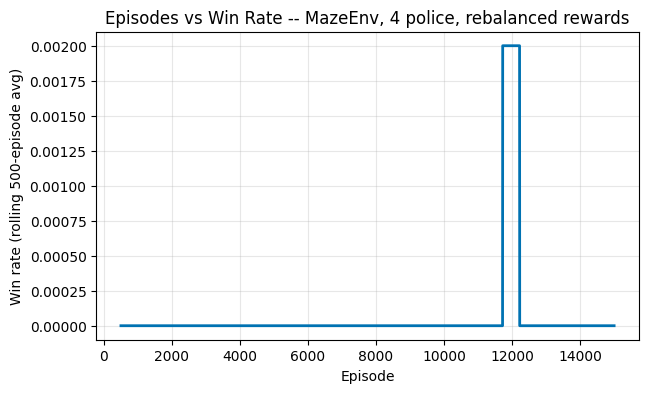

saved: c:\Users\leekh\OneDrive - Amrita vishwa vidyapeetham\Reinforcement Learning\Lab\Lab3\timeout_death_rate.png


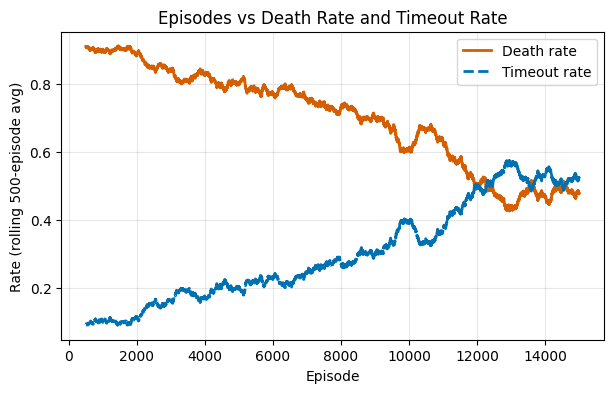

saved: c:\Users\leekh\OneDrive - Amrita vishwa vidyapeetham\Reinforcement Learning\Lab\Lab3\avg_reward.png


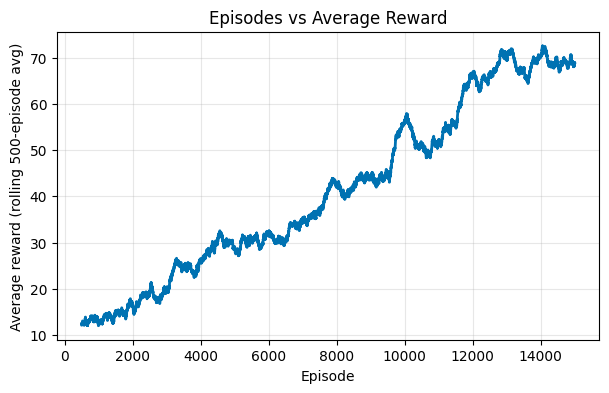

saved: c:\Users\leekh\OneDrive - Amrita vishwa vidyapeetham\Reinforcement Learning\Lab\Lab3\avg_steps.png


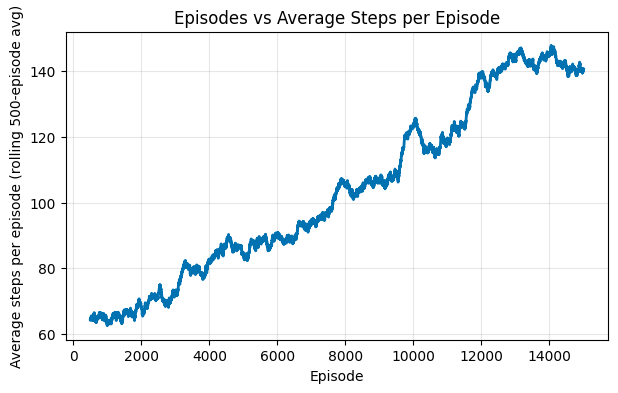

In [26]:
WINDOW = 500
OUT_DIR = r"c:\Users\leekh\OneDrive - Amrita vishwa vidyapeetham\Reinforcement Learning\Lab\Lab3"

# Okabe-Ito colorblind-safe pair: blue and vermillion
COLOR_MAIN = "#0072B2"
COLOR_DEATH = "#D55E00"
COLOR_TIMEOUT = "#0072B2"

def rolling_mean(x, window):
    x = np.asarray(x, dtype=float)
    csum = np.cumsum(np.insert(x, 0, 0))
    return (csum[window:] - csum[:-window]) / window

outcomes_arr = np.array(history_4police["outcome"])
win_flags = (outcomes_arr == "win").astype(float)
death_flags = (outcomes_arr == "death").astype(float)
timeout_flags = (outcomes_arr == "timeout").astype(float)
reward_arr = np.array(history_4police["reward"])
steps_arr = np.array(history_4police["steps"])

win_rate_roll = rolling_mean(win_flags, WINDOW)
death_rate_roll = rolling_mean(death_flags, WINDOW)
timeout_rate_roll = rolling_mean(timeout_flags, WINDOW)
reward_roll = rolling_mean(reward_arr, WINDOW)
steps_roll = rolling_mean(steps_arr, WINDOW)
roll_episodes = np.arange(1, len(outcomes_arr) + 1)[WINDOW - 1:]

def save_plot(fig, filename):
    path = f"{OUT_DIR}\\{filename}"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print("saved:", path)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(roll_episodes, win_rate_roll, color=COLOR_MAIN, linewidth=2)
ax.set_xlabel("Episode")
ax.set_ylabel(f"Win rate (rolling {WINDOW}-episode avg)")
ax.set_title("Episodes vs Win Rate -- MazeEnv, 4 police, rebalanced rewards")
ax.grid(alpha=0.3)
save_plot(fig, "win_rate.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(roll_episodes, death_rate_roll, color=COLOR_DEATH, linewidth=2, label="Death rate")
ax.plot(roll_episodes, timeout_rate_roll, color=COLOR_TIMEOUT, linewidth=2, linestyle="--", label="Timeout rate")
ax.set_xlabel("Episode")
ax.set_ylabel(f"Rate (rolling {WINDOW}-episode avg)")
ax.set_title("Episodes vs Death Rate and Timeout Rate")
ax.legend()
ax.grid(alpha=0.3)
save_plot(fig, "timeout_death_rate.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(roll_episodes, reward_roll, color=COLOR_MAIN, linewidth=2)
ax.set_xlabel("Episode")
ax.set_ylabel(f"Average reward (rolling {WINDOW}-episode avg)")
ax.set_title("Episodes vs Average Reward")
ax.grid(alpha=0.3)
save_plot(fig, "avg_reward.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(roll_episodes, steps_roll, color=COLOR_MAIN, linewidth=2)
ax.set_xlabel("Episode")
ax.set_ylabel(f"Average steps per episode (rolling {WINDOW}-episode avg)")
ax.set_title("Episodes vs Average Steps per Episode")
ax.grid(alpha=0.3)
save_plot(fig, "avg_steps.png")
plt.show()


<!-- STEP20_MARKER -->
## Observation Table and Discussion (final, copy-pasteable)

Printed as plain text below (not embedded in code comments) so both can be copied directly into
the report / .tex file. The Observation Table deviates from the lab handout's Tic-Tac-Toe-shaped
template (no "blocking," "center preference," or "corner preference" apply to this problem) and
instead reports what was actually observed.


In [27]:
observation_table = """
OBSERVATION TABLE

Initial Behaviour:
In the first 1,000 episodes, the thief dies in 90.5% of episodes and times out in only 9.5%
(0% wins). Average reward is low (12.34) and episodes are short (63.7 steps average) -- the
agent is essentially wandering into police almost immediately, consistent with a near-random
early policy (epsilon starts at 1.0).

Mid Training (episodes 7,000-8,000):
Death rate has fallen from 90.5% to 73.6% and timeout rate risen to 26.4%; average reward nearly
tripled to 39.62 and average survival time grew to 101.2 steps. The agent is clearly learning to
avoid police for longer, though still with zero wins in this window.

Final Behaviour (last 2,000 training episodes):
Death and timeout are roughly even (48.2% vs 51.8%), average reward reached 68.79 and average
survival time reached 142.4 steps out of the 200-step cap -- but win rate over these 2,000
episodes is still 0%. Only one win was ever recorded across all 15,000 training episodes, at
episode 11,721 (116 steps, reward 210.85, zero kills). Under pure-greedy evaluation (epsilon
fixed at 0, 300 fresh episodes), win rate remained 0.000, average reward 57.96, average steps
127.3, split 56% death / 44% timeout. This exposes an important gap: training-time reward climbs
because the potential-based shaping term rewards any incremental progress toward the treasure
even in episodes that ultimately end in death or timeout, and because epsilon-greedy occasionally
produces lucky escapes; the deterministic greedy policy has learned to survive substantially
longer, but has not learned a reliable route to actually complete the corridor.

Avoidance vs Aggression tendency:
Overwhelmingly avoidance-oriented. Average kills per episode stayed under 0.02 throughout
training (0.003 early, peaking at 0.013 mid-training, 0.0055 late) -- the back-attack mechanic
was essentially never exploited as a strategy. The learned policy is about staying away from
police, not fighting them.

Route efficiency:
Cannot be assessed as an efficient path to the treasure in any meaningful sense, since the policy
essentially never completes the route (1 win in 15,000 training episodes, 0 in 300 greedy
episodes). What the steps-per-episode trend does show clearly is a survival-efficiency
improvement: average steps per episode rose from 63.7 (early) to 142.4 (late training) -- the
agent got much better at staying alive, which is a real learned skill, just not the target skill
of reaching the treasure. The one recorded win took 116 steps against a 32-step shortest path --
more than 3x optimal, consistent with an opportunistic outcome of a survival-focused policy
rather than a deliberate, efficient route.

Risk-taking near treasure vs early game:
The single recorded win (episode 11,721, 116 steps) does not give enough signal to reliably
characterize treasure-proximity risk-taking -- one data point cannot distinguish "took more risks
near the goal" from "got a lucky police configuration." What is visible in aggregate is the
death/timeout balance shifting over training (from 90.5%/9.5% early to 48.2%/51.8% late), which
reflects growing overall risk-aversion (surviving longer in general), not treasure-specific
risk-taking.
"""

discussion_text = """
DISCUSSION

CO2 -- formulation quality. The original reward formulation used straight-line (Manhattan)
distance to the treasure as the potential function for reward shaping. This turned out to be a
formulation bug, not a minor tuning issue: the maze's fixed wall layout forces a mandatory
detour (the true shortest path is 32 steps, not the 18-step straight-line distance), and for a
large fraction of that detour, the correct move increases straight-line distance to the
treasure even though it is the only way to make progress. Manhattan-distance shaping therefore
actively penalized the one path that actually works. The general lesson is that potential-based
reward shaping (Ng, Harada and Russell, 1999) only preserves optimal-policy invariance if the
potential function accurately reflects the environment's true structure; a naive proxy such as
straight-line distance is not a safe default whenever the state space has walls, obstacles, or
any other structure that makes straight-line distance diverge from true reachability. The fix
was to precompute the true walls-aware shortest-path distance via breadth-first search from the
treasure once per maze layout, and use that as the potential function instead.

CO4 -- sample complexity and convergence. With 8 police units, a mandatory 32-step corridor, and
15,000 training episodes, both Q-learning and SARSA reached exactly zero wins, even after the
shaping bug above was fixed and after rewards were rebalanced (death penalty softened from -50
to -30, treasure reward raised from +100 to +150). Pure-greedy evaluation of the trained
policies confirmed this was not an artifact of leftover exploration noise: the learned policies
had genuinely not discovered a working route to the treasure. Reducing the police count to 4
under the same fixes produced a qualitatively different result: reward and survival time were
still climbing at episode 15,000 rather than having plateaued, and a single win was recorded.
This is best read as evidence that the original 8-police design exceeded the practical sample
complexity achievable with tabular Q-learning within a reasonable episode budget for this
course, not as evidence that tabular methods are incapable of solving this class of problem in
general -- the credit-assignment problem of propagating a sparse terminal reward backward across
a long, stochastic, mandatory chokepoint is intrinsically harder than propagating it across a
short or unconstrained path, and 8 independently-random police multiply that stochasticity
considerably.

CO5 -- exploration vs exploitation. Rebalancing the reward structure (softening the death
penalty and increasing the treasure reward) produced a measurable, theoretically-predicted shift
in the agent's risk posture: under pure-greedy evaluation, the fraction of episodes ending in
timeout (a proxy for risk-averse, corridor-avoiding behavior) fell from 37% under the original
reward magnitudes to 26.3% under the rebalanced ones, meaning the agent became relatively more
willing to attempt the corridor once death became cheaper and the treasure became more
valuable. This confirms that the expected-value balance between a guaranteed timeout penalty
and a risky attempt at the treasure is a real lever on the exploitation behavior of a trained
policy, even though in this case the shift was not large enough by itself to produce a
reliably winning policy. It is a concrete illustration of how the relative magnitudes of
terminal rewards shape what a converged (or near-converged) policy chooses to exploit,
independent of the epsilon-greedy exploration schedule used during training.

Limitations and future work. Within the time available for this course, the environment was
scaled down to 4 police to obtain a demonstrable, still-improving learning curve, rather than
fully solving the original 8-police design. If continued beyond the course deadline, promising
next steps would include: training for a substantially larger episode budget on the 4-police
setup to see whether the still-rising reward and survival-time trend eventually produces a
reliable win rate; redesigning the maze with a shorter or branching path so the mandatory
detour is less punishing to sample-inefficient exploration; and curriculum learning, starting
training with fewer police and gradually increasing the count, which would let the agent first
learn the corridor route under low risk before having to learn to survive a denser police
presence while executing it. The MazeEnvRadar (8-directional radar state) comparison was not
re-evaluated under the corrected shaping and rebalanced rewards due to time constraints; the
only valid comparison available (from before these fixes) showed comparable reward trends to
the smaller state representation despite a much larger, more sparsely-covered state space
(0.2% vs 3.2% (state,action) coverage after 15,000 episodes), which is itself suggestive that
richer per-step perception did not clearly help under a fixed sample budget, but this should be
re-verified under the corrected reward signal before being reported as a firm conclusion.
"""

print(observation_table)
print(discussion_text)



OBSERVATION TABLE

Initial Behaviour:
In the first 1,000 episodes, the thief dies in 90.5% of episodes and times out in only 9.5%
(0% wins). Average reward is low (12.34) and episodes are short (63.7 steps average) -- the
agent is essentially wandering into police almost immediately, consistent with a near-random
early policy (epsilon starts at 1.0).

Mid Training (episodes 7,000-8,000):
Death rate has fallen from 90.5% to 73.6% and timeout rate risen to 26.4%; average reward nearly
tripled to 39.62 and average survival time grew to 101.2 steps. The agent is clearly learning to
avoid police for longer, though still with zero wins in this window.

Final Behaviour (last 2,000 training episodes):
Death and timeout are roughly even (48.2% vs 51.8%), average reward reached 68.79 and average
survival time reached 142.4 steps out of the 200-step cap -- but win rate over these 2,000
episodes is still 0%. Only one win was ever recorded across all 15,000 training episodes, at
episode 11,721 (11